# MF 731 — Corporate Risk Management
## Homework: Estimating the Volatility of SPY (MA, EWMA, GARCH(1,1))

**Notebook:** `volatility_homework.ipynb`
**Repository:** <https://github.com/zhuchenpop-afk/MF731/blob/main/volatility_homework.ipynb>

---
## 1. Package imports

Only the five packages listed in `requirements.txt` are imported. If one is
missing the cell stops with the exact `pip` command needed.

In [1]:
import sys

_REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "yfinance": "yfinance",
}
_missing = []
for _mod, _pkg in _REQUIRED.items():
    try:
        __import__(_mod)
    except ImportError:
        _missing.append(_pkg)
if _missing:
    raise ImportError(
        "Missing package(s): " + ", ".join(_missing) + "\n"
        "Install them with:\n"
        "    pip install " + " ".join(_missing) + "\n"
        "or:\n"
        "    pip install -r requirements.txt"
    )

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy
from scipy.optimize import minimize
import yfinance as yf

pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("scipy      ", scipy.__version__)
print("matplotlib ", matplotlib.__version__)
print("yfinance   ", yf.__version__)

python      3.13.5
numpy       2.1.3
pandas      2.2.3
scipy       1.15.3
matplotlib  3.10.0
yfinance    0.2.66


---
## 2. Notation and configuration

Symbols used throughout:

| Symbol | Meaning | Name in code |
|---|---|---|
| $s_i$ | daily **closing** price | `close` |
| $x_i=\log(s_i/s_{i-1})$ | daily log return | `x` |
| $n$ | moving-average look-back | `N_MA` $=100$ |
| $\lambda$ | EWMA decay parameter | `LAM` $=0.94$ |
| $\Delta$ | length of one period, in years | `DELTA` $=1/252$ |
| $\hat\sigma_i^2$ | daily **variance** estimate for day $i$ | `ma_var`, `ewma_var` |
| $\hat\sigma_{A,i}^2=\hat\sigma_i^2/\Delta$ | **annualized** variance | — |
| $\alpha_0,\alpha_1,\beta_1$ | GARCH(1,1) parameters | `alpha0`, `alpha1`, `beta1` |
| $V_L=\alpha_0/(1-\alpha_1-\beta_1)$ | long-run variance | `V_L` |
| $M$ | number of simulated sample paths | `M_PATHS` $=100$ |

**Prices.** The assignment says *daily closing prices*, so the `Close` column is
used. `yfinance` is called with `auto_adjust=False` so that the library does not
silently replace `Close` by the dividend/split-adjusted series. (`Adj Close` is
downloaded as well but never used.)

**Dates.** `yfinance` treats `end` as *exclusive*, so the download runs a few days
past 07/30/2026 and the frame is then truncated to $\le$ 07/30/2026. Nothing is
forward-filled: only actual trading days appear.

In [2]:
# ----- data -----------------------------------------------------------------
TICKER          = "SPY"
DOWNLOAD_START  = "2021-01-01"   # early enough for the 100-day initialisation
DOWNLOAD_END    = "2026-08-06"   # yfinance `end` is EXCLUSIVE -> ask for more
DATA_END        = "2026-07-30"   # ... and truncate to this inclusive last date
CSV_PATH        = Path("SPY_data.csv")

# ----- Question 1 -----------------------------------------------------------
N_MA        = 100          # moving-average look-back, n = 100
LAM         = 0.94         # EWMA decay parameter, lambda = 0.94
DELTA       = 1.0 / 252.0  # Delta = 1/252 year
PLOT_START  = "2021-08-01" # 08/01/2021
PLOT_END    = "2026-07-30" # 07/30/2026
FIG1_PATH   = Path("ma_ewma_volatility.png")

# ----- Question 2 (GARCH fit window) ----------------------------------------
FIT_START   = "2025-06-01"
FIT_END     = "2026-05-31"

# ----- Question 3 (forecast window) -----------------------------------------
FC_START    = "2026-06-01"
FC_END      = "2026-07-30"
M_PATHS     = 100          # M = 100 sample paths
SEED        = 731          # fixed seed -> identical paths on every run
FIG2_PATH   = Path("garch_forecast_comparison.png")

# ----- figure style (validated, colour-blind-safe, print friendly) ----------
C_MA     = "#2a78d6"   # blue    - MA(100)
C_EWMA   = "#eb6834"   # orange  - EWMA(0.94)
C_MEAN   = "#4a3aa7"   # violet  - mean of the simulated paths
C_PATHS  = "#8a8a85"   # grey    - the M simulated paths
C_INK    = "#0b0b0b"   # ink     - analytic reference curve
FIG_DPI  = 200

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": FIG_DPI, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.labelsize": 11, "legend.frameon": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

print(f"n = {N_MA}, lambda = {LAM}, Delta = 1/252, M = {M_PATHS}, seed = {SEED}")

n = 100, lambda = 0.94, Delta = 1/252, M = 100, seed = 731


---
## 3. SPY data acquisition

Daily closing prices $\{s_0,s_1,\dots,s_N\}$ are downloaded once and cached, so
every later run is reproducible without network access.

### Pseudocode — data acquisition

```
INPUT : ticker T, first calendar date d0, last calendar date d1, cache file F
OUTPUT: a table of trading days with their closing prices, in date order

1  if the cache file F already exists
2        read the stored table from F                     (no network access)
3  else
4        request from the price provider every quoted trading day for T
             between d0 and the day after d1
             with raw, non-adjusted prices
5        if the request fails or returns nothing
6              stop and report that the provider is unreachable;
               do NOT continue with substituted or invented prices
7        keep only rows whose date is <= d1
8        sort the rows by date and make sure each date appears once
9        write the table to F so the next run needs no network
10 return the table
```

Two properties matter:

* after one successful run the analysis is fully reproducible **offline** — delete
  `SPY_data.csv` only if you want to re-download;
* if the provider is unreachable the cell raises; it never fabricates prices.

In [3]:
def _flatten_columns(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """yfinance may return MultiIndex columns ('Price','Ticker'); reduce to plain names."""
    if isinstance(df.columns, pd.MultiIndex):
        last = df.columns.get_level_values(-1)
        if ticker in set(last):
            df = df.xs(ticker, axis=1, level=-1)
        else:
            df = df.copy()
            df.columns = df.columns.get_level_values(0)
    return df


def _tidy(df: pd.DataFrame, end_inclusive: str) -> pd.DataFrame:
    """Naive DatetimeIndex, sorted, truncated at `end_inclusive`. No filling of any kind."""
    df = df.copy()
    idx = pd.to_datetime(df.index)
    if getattr(idx, "tz", None) is not None:
        idx = idx.tz_localize(None)
    df.index = pd.DatetimeIndex(idx.normalize(), name="Date")
    df = df.sort_index()
    df = df.loc[df.index <= pd.Timestamp(end_inclusive)]
    return df


def download_spy() -> pd.DataFrame:
    """Download raw (NON-adjusted) SPY OHLCV from Yahoo Finance."""
    try:
        raw = yf.download(
            TICKER,
            start=DOWNLOAD_START,
            end=DOWNLOAD_END,     # exclusive on Yahoo's side
            auto_adjust=False,    # <- keeps `Close` as the true closing price
            actions=False,
            progress=False,
        )
    except Exception as exc:                                     # noqa: BLE001
        raise RuntimeError(
            "Yahoo Finance download FAILED.\n"
            f"  reason: {exc!r}\n"
            "Check your internet connection and simply re-run this cell. "
            "No prices have been written and none are invented."
        ) from exc

    if raw is None or len(raw) == 0:
        raise RuntimeError(
            "Yahoo Finance returned an EMPTY table for "
            f"{TICKER} between {DOWNLOAD_START} and {DOWNLOAD_END}.\n"
            "This is usually a transient Yahoo error - re-run this cell. "
            "No prices are invented."
        )

    raw = _tidy(_flatten_columns(raw, TICKER), DATA_END)
    if "Close" not in raw.columns:
        raise RuntimeError(f"No 'Close' column in the download; got {list(raw.columns)}")
    return raw


# --------------------------------------------------------------- load or fetch
if CSV_PATH.exists():
    spy = pd.read_csv(CSV_PATH, index_col="Date", parse_dates=["Date"])
    spy = _tidy(spy, DATA_END)
    print(f"Loaded cached prices from {CSV_PATH.resolve()}  ({len(spy)} rows)")
else:
    print("No cache found - downloading from Yahoo Finance (this happens once) ...")
    spy = download_spy()
    spy.to_csv(CSV_PATH, index_label="Date")
    print(f"Downloaded and saved {len(spy)} rows to {CSV_PATH.resolve()}")

spy.head()

Loaded cached prices from /Users/chen/Downloads/SPY_data.csv  (1399 rows)


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-01-04,341.588684,368.790009,375.450012,364.820007,375.309998,110210800
2021-01-05,343.941345,371.329987,372.500000,368.049988,368.100006,66426200
2021-01-06,345.997589,373.549988,376.980011,369.119995,369.709991,107997700
2021-01-07,351.138214,379.100006,379.899994,375.910004,376.100006,68766800
2021-01-08,353.138977,381.260010,381.489990,377.100006,380.589996,71677200


---
## 4. Data validation

Checked before anything is computed: the ticker, first/last available dates, the
number of observations, chronological order, duplicated dates, missing closing
prices, and the column names. Weekends and exchange holidays are simply absent —
they are **not** filled in, so every row is a real trading day.

In [4]:
def validate(df: pd.DataFrame) -> None:
    print("=" * 78)
    print("DATA VALIDATION")
    print("=" * 78)
    print(f"ticker                  : {TICKER}")
    print(f"columns                 : {list(df.columns)}")
    print(f"number of observations  : {len(df)}")
    print(f"first available date    : {df.index[0].date()}")
    print(f"last available date     : {df.index[-1].date()}")

    chrono = bool(df.index.is_monotonic_increasing)
    n_dupes = int(df.index.duplicated().sum())
    n_nan = int(df["Close"].isna().sum())
    n_nonpos = int((df["Close"] <= 0).sum())
    print(f"chronologically ordered : {chrono}")
    print(f"duplicated dates        : {n_dupes}")
    print(f"missing closing prices  : {n_nan}")
    print(f"non-positive closes     : {n_nonpos}")

    if not chrono:
        raise ValueError("Dates are not in increasing order.")
    if n_dupes:
        raise ValueError(f"{n_dupes} duplicated date(s) in the price table.")
    if n_nan or n_nonpos:
        raise ValueError("Missing or non-positive closing prices - log returns undefined.")

    # ---- coverage required by the assignment --------------------------------
    need_last = pd.Timestamp(PLOT_END)
    if df.index[-1] < need_last:
        raise ValueError(
            f"Data end {df.index[-1].date()} is before the required {need_last.date()}. "
            "Delete SPY_data.csv and re-run the download cell."
        )
    pre = int((df.index < pd.Timestamp(PLOT_START)).sum())
    if pre < N_MA + 1:
        raise ValueError(
            f"Only {pre} trading days before {PLOT_START}; at least {N_MA + 1} closing "
            f"prices are needed to form the first {N_MA}-day estimate. "
            "Move DOWNLOAD_START earlier, delete SPY_data.csv and re-run."
        )
    for label, a, b in [("GARCH fit", FIT_START, FIT_END), ("forecast", FC_START, FC_END)]:
        k = int(((df.index >= pd.Timestamp(a)) & (df.index <= pd.Timestamp(b))).sum())
        if k == 0:
            raise ValueError(f"No trading days in the {label} window {a} - {b}.")
        print(f"trading days in {label:10s} window {a} - {b}: {k}")

    print(f"trading days strictly before {PLOT_START}: {pre}   (need >= {N_MA + 1})  OK")
    print("=" * 78)


validate(spy)

print("\nFIRST FIVE ROWS")
print(spy.head())
print("\nLAST FIVE ROWS")
print(spy.tail())
print(f"\nfirst date = {spy.index[0].date()}   "
      f"last date = {spy.index[-1].date()}   "
      f"observations = {len(spy)}")

DATA VALIDATION
ticker                  : SPY
columns                 : ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
number of observations  : 1399
first available date    : 2021-01-04
last available date     : 2026-07-30
chronologically ordered : True
duplicated dates        : 0
missing closing prices  : 0
non-positive closes     : 0
trading days in GARCH fit  window 2025-06-01 - 2026-05-31: 250
trading days in forecast   window 2026-06-01 - 2026-07-30: 42
trading days strictly before 2021-08-01: 145   (need >= 101)  OK

FIRST FIVE ROWS
            Adj Close      Close       High        Low       Open     Volume
Date                                                                        
2021-01-04 341.588684 368.790009 375.450012 364.820007 375.309998  110210800
2021-01-05 343.941345 371.329987 372.500000 368.049988 368.100006   66426200
2021-01-06 345.997589 373.549988 376.980011 369.119995 369.709991  107997700
2021-01-07 351.138214 379.100006 379.899994 375.910004 376.1

---
## 5. Daily log returns

The log return over $[t,t+\Delta]$ is

$$X_{t+\Delta}=\log\!\left(\frac{S_{t+\Delta}}{S_t}\right),$$

which on the observed prices becomes

$$\boxed{\;x_i=\log\!\left(\frac{s_i}{s_{i-1}}\right),\qquad i=1,\dots,N\;}$$

where $s_i$ is the **closing** price on trading day $i$. These are *log* returns,
not simple percentage returns, and they are the returns fed to every estimator
below (MA, EWMA and GARCH).

`N+1` closing prices give `N` returns: the first price has no predecessor, so the
return series starts one trading day after the price series.

### Pseudocode — log returns

```
INPUT : closing prices s[0..N] in date order
OUTPUT: log returns x[1..N], the return x[i] carrying the date of day i

1  for each trading day i from 1 to N
2        x[i] <- natural log of ( s[i] / s[i-1] )
3  the first day has no predecessor, so it produces no return
4  return x
```

In [5]:
close = spy["Close"].astype(float)
close.name = "Close"

# x_i = log( s_i / s_{i-1} ) ; the return is dated on day i (the later day)
x = np.log(close / close.shift(1)).dropna()
x.name = "log_return"

print(f"closing prices : {len(close)}  ({close.index[0].date()} -> {close.index[-1].date()})")
print(f"log returns    : {len(x)}  ({x.index[0].date()} -> {x.index[-1].date()})")
assert len(x) == len(close) - 1

print("\nfirst three returns, checked by hand:")
for i in range(1, 4):
    s1, s0 = close.iloc[i], close.iloc[i - 1]
    print(f"  {close.index[i].date()}  log({s1:.4f}/{s0:.4f}) = {np.log(s1 / s0): .8f}"
          f"   (series value {x.iloc[i - 1]: .8f})")

print(f"\nsample mean of x  : {x.mean(): .8e}   (≈ 0, the stylised fact used by the simplified MA)")
print(f"sample sd   of x  : {x.std(ddof=1): .8e}  per day"
      f"  ->  {x.std(ddof=1) * np.sqrt(252) * 100:.2f}% annualised over the whole sample")

closing prices : 1399  (2021-01-04 -> 2026-07-30)
log returns    : 1398  (2021-01-05 -> 2026-07-30)

first three returns, checked by hand:
  2021-01-05  log(371.3300/368.7900) =  0.00686372   (series value  0.00686372)
  2021-01-06  log(373.5500/371.3300) =  0.00596071   (series value  0.00596071)
  2021-01-07  log(379.1000/373.5500) =  0.01474821   (series value  0.01474821)

sample mean of x  :  4.99788247e-04   (≈ 0, the stylised fact used by the simplified MA)
sample sd   of x  :  1.05972261e-02  per day  ->  16.82% annualised over the whole sample


---
## 6. Question 1(a) — moving-average volatility, $n=100$

The moving-average estimator over a rolling window of $n$ returns:

$$\hat\mu_i=\frac1n\sum_{j=0}^{n-1}x_{i-j},
\qquad
\boxed{\;\hat\sigma_i^{\,2}=\frac{1}{n-1}\sum_{j=0}^{n-1}\bigl(x_{i-j}-\hat\mu_i\bigr)^2\;},
\qquad i=n,\dots,N .$$

Four conventions are fixed explicitly rather than inherited from a library default:

1. **Denominator** $n-1$ — the unbiased sample variance — *not* $n$.
2. **The sample mean $\hat\mu_i$ is subtracted.** A *simplified* variant sets
   $\hat\mu=0$ and divides by $n$; it is computed underneath purely as a
   cross-check, and the two differ by a fraction of a percentage point of
   annualized volatility.
3. **Window.** $\hat\sigma_i^2$ uses the $n$ returns $x_i,x_{i-1},\dots,x_{i-n+1}$,
   i.e. **today's return belongs to today's estimate** ($j=0,\dots,n-1$).
4. **No look-ahead bias.** $\hat\sigma_i^2$ uses only returns realised up to and
   including day $i$, all of which are known at the close of day $i$.

The first estimate therefore appears on the $n$-th return, i.e. 100 trading days
after the return series begins, which is why the download starts in January 2021
although the plot starts on 08/01/2021.

### Pseudocode — MA($n$)

```
INPUT : log returns x[1..N], window length n
OUTPUT: daily variance estimate v[i] for every day i >= n

1  for each day i from n to N
2        W <- the n most recent returns, x[i-n+1] ... x[i]      (today included)
3        m <- the arithmetic average of the values in W
4        v[i] <- ( sum over W of (value - m) squared ) / (n - 1)
5  days before day n have too little history: leave them undefined
6  return v
```

In [6]:
def ma_variance(returns: pd.Series, n: int) -> pd.Series:
    """MA(n) daily variance: sample mean removed, divided by n-1, today's return included."""
    a = np.asarray(returns, dtype=float)
    out = np.full(a.size, np.nan)
    for i in range(n - 1, a.size):          # 0-based: i = n-1 is the n-th return
        w = a[i - n + 1: i + 1]             # x_{i-n+1}, ..., x_i  (n values, today included)
        mu = w.sum() / n                    # mu-hat_i
        out[i] = ((w - mu) ** 2).sum() / (n - 1)
    return pd.Series(out, index=returns.index, name=f"MA({n})_variance")


def ma_variance_simplified(returns: pd.Series, n: int) -> pd.Series:
    """Simplified MA variant: mu-hat = 0 and division by n. Computed as a cross-check only."""
    a = np.asarray(returns, dtype=float)
    out = np.full(a.size, np.nan)
    for i in range(n - 1, a.size):
        out[i] = (a[i - n + 1: i + 1] ** 2).sum() / n
    return pd.Series(out, index=returns.index, name=f"MA({n})_variance_simplified")


ma_var      = ma_variance(x, N_MA)
ma_var_simp = ma_variance_simplified(x, N_MA)

# --- convention check: our explicit loop must equal the (n-1, mean-removed) rolling variance
_pandas_ref = x.rolling(N_MA).var(ddof=1)
assert np.allclose(ma_var.dropna().to_numpy(), _pandas_ref.dropna().to_numpy(),
                   rtol=1e-12, atol=0.0), \
    "MA implementation does not match the (mean removed, n-1) sample variance."
print("convention check: explicit loop == sample variance with mean removed and denominator n-1  OK")

first_pos = N_MA - 1
print(f"first MA({N_MA}) estimate on {ma_var.index[first_pos].date()} "
      f"(the {N_MA}-th return, from returns "
      f"{x.index[0].date()} ... {x.index[first_pos].date()})")
print(f"defined estimates: {int(ma_var.notna().sum())} of {len(ma_var)} days")

_d = (np.sqrt(ma_var / DELTA) - np.sqrt(ma_var_simp / DELTA)).dropna().abs()
print(f"\ncross-check against the simplified MA (mu=0, /n): "
      f"max |difference| in annualised volatility = {_d.max() * 100:.4f} percentage points, "
      f"mean = {_d.mean() * 100:.4f} pp")

convention check: explicit loop == sample variance with mean removed and denominator n-1  OK
first MA(100) estimate on 2021-05-27 (the 100-th return, from returns 2021-01-05 ... 2021-05-27)
defined estimates: 1299 of 1398 days

cross-check against the simplified MA (mu=0, /n): max |difference| in annualised volatility = 0.5816 percentage points, mean = 0.0712 pp


---
## 7. Question 1(b) — EWMA volatility, $\lambda = 0.94$

The exponentially weighted moving average is defined recursively by

$$\hat\sigma_{t+\Delta}^{\,2}=\lambda\,\hat\sigma_t^{\,2}+(1-\lambda)\,x_t^{\,2},$$

which on the observed returns is implemented as

$$\boxed{\;\hat\sigma_i^{\,2}=\lambda\,\hat\sigma_{i-1}^{\,2}+(1-\lambda)\,x_{i-1}^{\,2},
\qquad i=n,\dots,N\;}$$

**Indexing — the one subtle point.** The recursion uses $x_{i-1}$, *not* $x_i$: the
EWMA estimate carried by day $i$ is built from returns up to day $i-1$ only. That
is the definition $\hat\sigma^2_{t+\Delta}=\lambda\hat\sigma^2_t+(1-\lambda)x_t^2$
read with $t\leftrightarrow i-1$ and $t+\Delta\leftrightarrow i$.

A consequence worth noting: MA at day $i$ uses returns through $x_i$ while EWMA at
day $i$ uses returns through $x_{i-1}$, so the EWMA curve sits one trading day
later relative to the MA curve. Neither estimator ever uses a future return, so
**neither has look-ahead bias**.

**Initialization.** The recursion needs a starting variance. It is set to the
sample variance of the preceding 100 returns:

$$\hat\sigma_n^{\,2}\;:=\;\hat\sigma_{\mathrm{MA}(100),\,n}^{\,2}
=\frac{1}{n-1}\sum_{j=0}^{n-1}(x_{n-j}-\hat\mu_n)^2 ,$$

i.e. the MA(100) value on the very first day it exists, so the MA and EWMA curves
start from the same number and the recursion then runs forward from day $n+1$.
Written as a weighted sum rather than a recursion, this starting value is the
anchor $\hat\sigma^2_{t-n\Delta}$ carrying weight $\lambda^n$, with the remaining
returns weighted $(1-\lambda)\lambda^{i-1}$.

### Pseudocode — EWMA($\lambda$)

```
INPUT : log returns x[1..N], decay lambda in (0,1), start day n,
        starting variance v0 = sample variance of the n returns up to day n
OUTPUT: daily variance estimate w[i] for every day i >= n

1  w[n] <- v0                                        (initialisation allowed by the HW)
2  for each day i from n+1 to N
3        w[i] <- lambda * w[i-1] + (1 - lambda) * (the PREVIOUS day's return) squared
4  days before day n are left undefined
5  return w
```

In [7]:
def ewma_variance(returns: pd.Series, lam: float, start_pos: int, var_start: float) -> pd.Series:
    """EWMA daily variance:  w_i = lam*w_{i-1} + (1-lam)*x_{i-1}^2  (note: x_{i-1}, not x_i)."""
    a = np.asarray(returns, dtype=float)
    out = np.full(a.size, np.nan)
    out[start_pos] = var_start                      # initial variance (HW: sample var of past 100)
    for i in range(start_pos + 1, a.size):
        out[i] = lam * out[i - 1] + (1.0 - lam) * a[i - 1] ** 2   # NOTE: x_{i-1}, not x_i
    return pd.Series(out, index=returns.index, name=f"EWMA({lam})_variance")


ewma_start_pos = N_MA - 1                            # 0-based position of the n-th return
ewma_var0 = float(ma_var.iloc[ewma_start_pos])       # sample variance over the past 100 days
ewma_var = ewma_variance(x, LAM, ewma_start_pos, ewma_var0)

print(f"EWMA initialised on {x.index[ewma_start_pos].date()} with the MA({N_MA}) sample variance")
print(f"  sigma^2_init = {ewma_var0:.10e}  ->  sigma_init = {np.sqrt(ewma_var0)*100:.4f}% per day"
      f"  ->  {np.sqrt(ewma_var0/DELTA)*100:.2f}% annualised")

# hand check of the first two recursion steps
for k in (1, 2):
    i = ewma_start_pos + k
    manual = LAM * ewma_var.iloc[i - 1] + (1 - LAM) * x.iloc[i - 1] ** 2
    print(f"  {x.index[i].date()}: {LAM}*{ewma_var.iloc[i-1]:.6e} + {1-LAM:.2f}*"
          f"({x.iloc[i-1]: .6f})^2 = {manual:.10e}   series = {ewma_var.iloc[i]:.10e}")
    assert abs(manual - ewma_var.iloc[i]) <= 1e-12 * abs(manual)

print(f"\ndefined estimates: {int(ewma_var.notna().sum())} of {len(ewma_var)} days")

EWMA initialised on 2021-05-27 with the MA(100) sample variance
  sigma^2_init = 8.1684232236e-05  ->  sigma_init = 0.9038% per day  ->  14.35% annualised
  2021-05-28: 0.94*8.168423e-05 + 0.06*( 0.000525)^2 = 7.6799705542e-05   series = 7.6799705542e-05
  2021-06-01: 0.94*7.679971e-05 + 0.06*( 0.001787)^2 = 7.2383355411e-05   series = 7.2383355411e-05

defined estimates: 1299 of 1398 days


---
## 8. Annualization

Under the i.i.d. hypothesis variance is linear in time, so the **annualized
variance** is

$$\hat\sigma_{A,t+\Delta}^{\,2}=\frac{\hat\sigma_{t+\Delta}^{\,2}}{\Delta},
\qquad \Delta=\frac{1}{252},$$

and the **volatility** is annualized by multiplying by $\sqrt{1/\Delta}=\sqrt{252}$:

$$\boxed{\;\hat\sigma_{A,i}=\sqrt{\hat\sigma_i^{\,2}/\Delta}=\hat\sigma_i\sqrt{252}\;}$$

The variance is divided by $\Delta$; the **volatility is multiplied by $\sqrt{252}$,
never by $252$**.

In [8]:
def annualize_vol(daily_var, delta: float = DELTA):
    """Annualised volatility from a daily VARIANCE: sqrt(var/Delta) = sqrt(var)*sqrt(252)."""
    return np.sqrt(daily_var / delta)


ma_vol_ann   = annualize_vol(ma_var).rename(f"MA({N_MA})")
ewma_vol_ann = annualize_vol(ewma_var).rename(f"EWMA({LAM})")

assert abs(1 / DELTA - 252.0) < 1e-12
_k = ma_var.dropna().index[0]
print(f"scaling check on {_k.date()}: daily variance {ma_var[_k]:.8e} -> daily vol "
      f"{np.sqrt(ma_var[_k])*100:.4f}% -> annualised {ma_vol_ann[_k]*100:.4f}% "
      f"(= daily vol x sqrt(252) = {np.sqrt(ma_var[_k])*np.sqrt(252)*100:.4f}%)")

mask = (ma_vol_ann.index >= pd.Timestamp(PLOT_START)) & (ma_vol_ann.index <= pd.Timestamp(PLOT_END))
ma_plot, ewma_plot = ma_vol_ann[mask], ewma_vol_ann[mask]

assert ma_plot.notna().all(),   "MA has gaps inside the plotting window."
assert ewma_plot.notna().all(), "EWMA has gaps inside the plotting window."

print(f"\nplotting window {PLOT_START} -> {PLOT_END}: {len(ma_plot)} trading days "
      f"({ma_plot.index[0].date()} -> {ma_plot.index[-1].date()})")
summary_q1 = pd.DataFrame({
    "MA(100) ann. vol %":     100 * ma_plot,
    "EWMA(0.94) ann. vol %":  100 * ewma_plot,
}).describe().loc[["mean", "std", "min", "max"]]
print(summary_q1)

scaling check on 2021-05-27: daily variance 8.16842322e-05 -> daily vol 0.9038% -> annualised 14.3473% (= daily vol x sqrt(252) = 14.3473%)

plotting window 2021-08-01 -> 2026-07-30: 1254 trading days (2021-08-02 -> 2026-07-30)
      MA(100) ann. vol %  EWMA(0.94) ann. vol %
mean           16.144720              15.834839
std             5.758956               6.638125
min             9.580639               7.300641
max            27.943375              51.770522


---
## 9. Question 1 — comparison figure

Both estimates on one figure over 08/01/2021 – 07/30/2026, as the question requires.
Saved as `ma_ewma_volatility.png` at 200 dpi, large enough to drop into the PDF.

### Pseudocode — comparison plot

```
INPUT : two annualised volatility series, a first and a last date
OUTPUT: one labelled figure saved to disk

1  restrict both series to the requested date range
2  draw each series against its dates on the SAME axes and the SAME y scale
3  label the x axis with dates, the y axis with annualised volatility in percent
4  give each series a name in the legend and give the figure a descriptive title
5  save the figure at a resolution high enough for print
```

saved /Users/chen/Downloads/ma_ewma_volatility.png


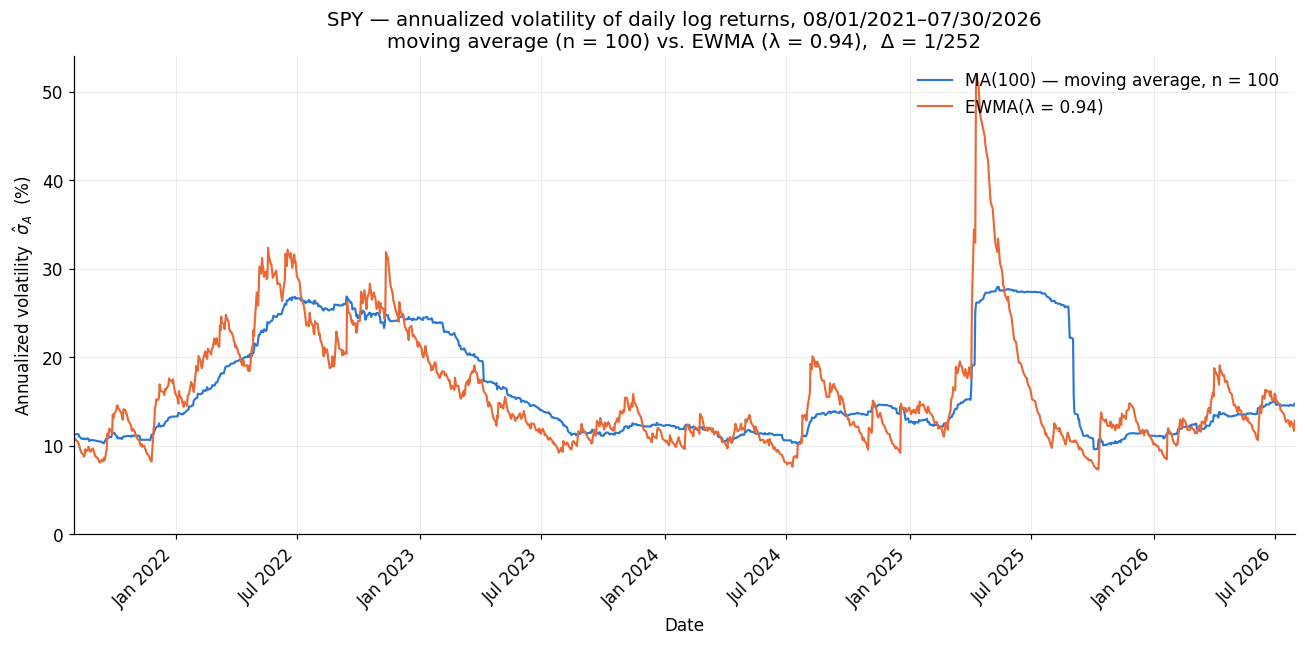

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(ma_plot.index,   100 * ma_plot.to_numpy(),   lw=1.4, color=C_MA,
        label=f"MA({N_MA}) — moving average, n = {N_MA}")
ax.plot(ewma_plot.index, 100 * ewma_plot.to_numpy(), lw=1.4, color=C_EWMA,
        label=f"EWMA(λ = {LAM})")

ax.set_title(f"SPY — annualized volatility of daily log returns, "
             f"{pd.Timestamp(PLOT_START):%m/%d/%Y}–{pd.Timestamp(PLOT_END):%m/%d/%Y}\n"
             f"moving average (n = {N_MA}) vs. EWMA (λ = {LAM}),  Δ = 1/252")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility  $\\hat{\\sigma}_{A}$  (%)")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_xlim(ma_plot.index[0], ma_plot.index[-1])
ax.set_ylim(bottom=0)
ax.legend(loc="upper right")
fig.autofmt_xdate(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG1_PATH, dpi=FIG_DPI, bbox_inches="tight")
print(f"saved {FIG1_PATH.resolve()}")
plt.show()

---
## 10. Question 2 — fitting GARCH(1,1) by maximum likelihood

### The model

For $\alpha_0>0$, $\alpha_1,\beta_1\ge 0$ with $\alpha_1+\beta_1<1$,

$$\sigma_{t+\Delta}^2=\alpha_0+\alpha_1X_t^2+\beta_1\sigma_t^2,
\qquad X_{t+\Delta}=\sigma_{t+\Delta}Z_{k+1},
\qquad Z_i\stackrel{\text{i.i.d.}}{\sim}N(0,1).$$

### The likelihood

Because $X_{t-i\Delta}\sim N(0,\sigma_{t-i\Delta}^2)$ conditionally,

$$\ln L(\theta)=-\frac12\sum_{i}\Bigl[\ln(2\pi)+\ln(\sigma^2_{t-i\Delta})
+\frac{x^2_{t-i\Delta}}{\sigma^2_{t-i\Delta}}\Bigr].$$

The $\ln(2\pi)$ term is constant, so maximizing the likelihood is *equivalent to*

$$\boxed{\;\hat\theta=(\hat\alpha_0,\hat\alpha_1,\hat\beta_1)
=\arg\min_{\theta}\;\sum_{i=1}^{n}\Bigl[\ln\sigma_i^2+\frac{x_i^2}{\sigma_i^2}\Bigr]\;}
\qquad\text{s.t.}\qquad
\sigma_i^2=\alpha_0+\alpha_1x_{i-1}^2+\beta_1\sigma_{i-1}^2 .$$

The recursion needs a starting value: $\sigma_1^2$ is fixed at the **sample
variance of the log returns in the fitting window**. (Setting it to zero would make
$\ln\sigma_1^2$ undefined.)

This objective is coded directly. The `arch` package is **not** used — it would
replace the likelihood being built here. The only library role is
`scipy.optimize.minimize`, a generic numerical minimizer performing the
"$\arg\min$", not a GARCH routine. The model is exactly as stated above: zero
conditional mean, Gaussian $Z$, no mean equation, no $t$-distribution and no
variance targeting.

### One numerical remark (exact, not a modelling choice)

Daily log returns are of order $10^{-2}$, so $\alpha_0$ is of order $10^{-6}$ and the
three parameters differ by six orders of magnitude, which makes the minimizer's
step sizes ill-scaled. The minimization is therefore carried out on
$y_i=c\,x_i$ with $c=100$ and then mapped back. This is an exact change of
variables, not a different model: with $\sigma^2_{y,i}=c^2\sigma^2_{x,i}$,

$$\sigma_{y,i}^2=A_0+A_1y_{i-1}^2+B_1\sigma_{y,i-1}^2
\iff
\sigma_{x,i}^2=\frac{A_0}{c^2}+A_1x_{i-1}^2+B_1\sigma_{x,i-1}^2,$$

$$\sum_i\Bigl[\ln\sigma_{y,i}^2+\frac{y_i^2}{\sigma_{y,i}^2}\Bigr]
=n\ln c^2+\sum_i\Bigl[\ln\sigma_{x,i}^2+\frac{x_i^2}{\sigma_{x,i}^2}\Bigr],$$

so the objectives differ by the constant $n\ln c^2$ and have the *same* minimizer,
with $\alpha_0=A_0/c^2$, $\alpha_1=A_1$, $\beta_1=B_1$. Both identities are verified
numerically below, and the optimum is re-checked directly on the raw returns.

### Date handling

06/01/2025 and 05/31/2026 are not both trading days. No observation is invented:
the fit uses the actual SPY closing prices *inside* that calendar interval, and
the returns computed from them ($K$ prices give $K-1$ returns). The first and last
trading observations actually used are printed below.

### Pseudocode — fitting GARCH(1,1) by MLE

```
INPUT : log returns x[1..n] of the fitting window
OUTPUT: fitted parameters a0, a1, b1

DEFINE  negative-log-likelihood( a0, a1, b1 ):
  1   v[1] <- the sample variance of x[1..n]            (starting value)
  2   for i from 2 to n
  3         v[i] <- a0 + a1 * x[i-1]^2 + b1 * v[i-1]    (the GARCH recursion)
  4   if any v[i] is not strictly positive, return a very large number
  5   return the sum over i of  ( log v[i] + x[i]^2 / v[i] )

  6   choose several sensible starting triples (a0, a1, b1)
  7   for each starting triple
  8         search for the triple minimising negative-log-likelihood,
              keeping a0 > 0, a1 >= 0, b1 >= 0 and a1 + b1 < 1
  9   keep the triple with the smallest value found
 10   verify: a0 > 0, a1 >= 0, b1 >= 0, a1 + b1 < 1     (existence of a long-run variance)
 11   return the fitted triple
```

In [10]:
# ---------------------------------------------------- fitting window (literal reading)
fit_prices = close.loc[(close.index >= pd.Timestamp(FIT_START)) &
                       (close.index <= pd.Timestamp(FIT_END))]
x_fit = np.log(fit_prices / fit_prices.shift(1)).dropna()
x_fit.name = "log_return_fit"

print("GARCH(1,1) FITTING WINDOW")
print(f"  requested calendar interval : {FIT_START} to {FIT_END}")
print(f"  closing prices used         : {len(fit_prices)}  "
      f"(first {fit_prices.index[0].date()}, last {fit_prices.index[-1].date()})")
print(f"  log returns used            : {len(x_fit)}  "
      f"(first {x_fit.index[0].date()}, last {x_fit.index[-1].date()})")
print("  no observation is invented: these are the actual SPY trading days in the interval")
print(f"  sample mean  of x_fit       : {x_fit.mean(): .8e}")
print(f"  sample var   of x_fit       : {x_fit.var(ddof=1): .8e}  "
      f"-> {np.sqrt(x_fit.var(ddof=1)/DELTA)*100:.2f}% annualised")

GARCH(1,1) FITTING WINDOW
  requested calendar interval : 2025-06-01 to 2026-05-31
  closing prices used         : 250  (first 2025-06-02, last 2026-05-29)
  log returns used            : 249  (first 2025-06-03, last 2026-05-29)
  no observation is invented: these are the actual SPY trading days in the interval
  sample mean  of x_fit       :  9.79802377e-04
  sample var   of x_fit       :  5.61816635e-05  -> 11.90% annualised


In [11]:
def garch_variance_path(params, r, var_init):
    """Conditional variance path: v_1 = var_init, v_i = a0 + a1 r_{i-1}^2 + b1 v_{i-1}."""
    a0, a1, b1 = params
    n = r.size
    v = np.empty(n)
    v[0] = var_init
    for i in range(1, n):
        v[i] = a0 + a1 * r[i - 1] ** 2 + b1 * v[i - 1]
    return v


def garch_nll(params, r, var_init):
    """Negative log-likelihood (constant dropped):  sum_i [ log v_i + r_i^2 / v_i ]."""
    a0, a1, b1 = params
    if a0 <= 0.0 or a1 < 0.0 or b1 < 0.0 or a1 + b1 >= 1.0:
        return 1e12
    v = garch_variance_path(params, r, var_init)
    if not np.all(np.isfinite(v)) or np.any(v <= 0.0):
        return 1e12
    val = float(np.sum(np.log(v) + r ** 2 / v))
    return val if np.isfinite(val) else 1e12


# ------------------------------------------------- minimise on the c = 100 scale
SCALE = 100.0
r_raw = x_fit.to_numpy()
r_scl = r_raw * SCALE
v0_raw = float(np.var(r_raw, ddof=1))          # sigma_1^2 = sample variance
v0_scl = float(np.var(r_scl, ddof=1))

bounds = [(1e-12, 10.0 * v0_scl), (0.0, 0.9990), (0.0, 0.9990)]
cons = [{"type": "ineq", "fun": lambda p: 0.9990 - (p[1] + p[2])}]   # a1 + b1 < 1

starts = []
for a1_0 in (0.03, 0.06, 0.10, 0.15, 0.25):
    for b1_0 in (0.60, 0.75, 0.85, 0.92):
        if a1_0 + b1_0 < 0.995:
            starts.append([max(1e-10, (1 - a1_0 - b1_0) * v0_scl), a1_0, b1_0])

best, best_f = None, np.inf
for s0 in starts:
    try:
        with warnings.catch_warnings():
            # SLSQP may step marginally outside the box and clip back; harmless here
            warnings.simplefilter("ignore", RuntimeWarning)
            res = minimize(garch_nll, s0, args=(r_scl, v0_scl), method="SLSQP",
                           bounds=bounds, constraints=cons,
                           options={"maxiter": 2000, "ftol": 1e-14})
    except Exception:                                            # noqa: BLE001
        continue
    if np.isfinite(res.fun) and res.fun < best_f - 1e-12:
        best, best_f = res, float(res.fun)

if best is None:
    raise RuntimeError("The GARCH(1,1) likelihood could not be minimised on this sample.")

A0, A1, B1 = best.x
alpha0 = A0 / SCALE ** 2          # exact rescaling back to raw daily log returns
alpha1 = A1
beta1  = B1

print(f"multi-start optimisation: {len(starts)} starting points, best -logL "
      f"(scaled) = {best_f:.8f}")
print(f"converged: {best.success}   iterations: {best.nit}   message: {best.message}")

multi-start optimisation: 14 starting points, best -logL (scaled) = 103.01329793
converged: True   iterations: 15   message: Optimization terminated successfully


In [12]:
# ------------------------------------------------------------------ diagnostics
nll_raw = garch_nll((alpha0, alpha1, beta1), r_raw, v0_raw)
n_fit = r_raw.size

print("=" * 78)
print("Q2 — FITTED GARCH(1,1) PARAMETERS  (daily log-return scale)")
print("=" * 78)
print(f"  alpha_0 = {alpha0: .10e}")
print(f"  alpha_1 = {alpha1: .8f}")
print(f"  beta_1  = {beta1: .8f}")
print(f"  minimised  -l(theta) = sum[ ln sigma_i^2 + x_i^2/sigma_i^2 ] = {nll_raw:.8f}")
print(f"     (negative because ln sigma_i^2 < 0 for daily variances of order 1e-4;")
print(f"      the constant ln(2 pi) term is dropped from the objective)")
loglik = -0.5 * (n_fit * np.log(2 * np.pi) + nll_raw)
print(f"  full Gaussian log-likelihood  ln L = -(1/2)[ n ln(2 pi) + (-l) ] = {loglik:.6f}"
      f"   (n = {n_fit})")

print("\nMODEL RESTRICTIONS  (alpha_0 > 0; alpha_1, beta_1 >= 0; alpha_1 + beta_1 < 1)")
ok_a0 = alpha0 > 0
ok_nn = (alpha1 >= 0) and (beta1 >= 0)
ok_st = (alpha1 + beta1) < 1
print(f"  alpha_0 > 0                     : {ok_a0}")
print(f"  alpha_1 >= 0 and beta_1 >= 0    : {ok_nn}")
print(f"  alpha_1 + beta_1 = {alpha1 + beta1:.8f} < 1 : {ok_st}")
assert ok_a0 and ok_nn and ok_st, "The fit violates a GARCH(1,1) parameter restriction."

V_L = alpha0 / (1.0 - alpha1 - beta1)
print(f"\n  persistence  alpha_1 + beta_1  = {alpha1 + beta1:.6f}")
print(f"  long-run variance  V_L = alpha_0/(1-alpha_1-beta_1) = {V_L:.10e}")
print(f"  long-run daily volatility      = {np.sqrt(V_L)*100:.4f}% per day")
print(f"  long-run annualised volatility = {np.sqrt(V_L/DELTA)*100:.2f}%")

# --- verification 1: the c=100 rescaling is exact --------------------------------
nll_scl = garch_nll((A0, A1, B1), r_scl, v0_scl)
gap = nll_scl - nll_raw
print("\nVERIFICATION 1 - exactness of the c = 100 change of variables")
print(f"  -l(scaled) - -l(raw) = {gap:.10f}   n*ln(c^2) = {n_fit*np.log(SCALE**2):.10f}   "
      f"difference = {abs(gap - n_fit*np.log(SCALE**2)):.3e}")
assert abs(gap - n_fit * np.log(SCALE ** 2)) < 1e-6

# --- verification 2: re-optimise directly on the raw returns ---------------------
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    res_raw = minimize(garch_nll, [alpha0, alpha1, beta1], args=(r_raw, v0_raw), method="SLSQP",
                       bounds=[(1e-16, 10 * v0_raw), (0.0, 0.999), (0.0, 0.999)],
                       constraints=[{"type": "ineq", "fun": lambda p: 0.999 - (p[1] + p[2])}],
                       options={"maxiter": 2000, "ftol": 1e-18})
print("\nVERIFICATION 2 - re-optimisation started from the fit, on the raw scale")
print(f"  -l at the reported fit = {nll_raw:.10f}")
print(f"  -l after re-optimising = {res_raw.fun:.10f}   change = {res_raw.fun - nll_raw:+.3e}")
print(f"  alpha_0 {alpha0:.6e} -> {res_raw.x[0]:.6e} | "
      f"alpha_1 {alpha1:.6f} -> {res_raw.x[1]:.6f} | beta_1 {beta1:.6f} -> {res_raw.x[2]:.6f}")
print("  (the badly scaled raw-parameter search cannot improve on the reported fit,")
print("   so the reported fit is the minimiser)")
assert res_raw.fun >= nll_raw - 1e-2, "A better optimum exists on the raw scale - investigate."

# --- verification 3: numerical gradient at the optimum ---------------------------
theta = [alpha0, alpha1, beta1]
steps = [alpha0 * 1e-4, 1e-6, 1e-6]
g, g_rel = [], []
for k, h in enumerate(steps):
    p_up, p_dn = list(theta), list(theta)
    p_up[k] += h
    p_dn[k] -= h
    gk = (garch_nll(p_up, r_raw, v0_raw) - garch_nll(p_dn, r_raw, v0_raw)) / (2 * h)
    g.append(gk)
    g_rel.append(gk * theta[k])       # change in -l per 100% relative move in the parameter
print("\nVERIFICATION 3 - central-difference gradient of -l at the optimum")
print(f"  d(-l)/d alpha_0 = {g[0]: .4e}   d(-l)/d alpha_1 = {g[1]: .4e}"
      f"   d(-l)/d beta_1 = {g[2]: .4e}")
print(f"  scaled by the parameter (comparable across the three): "
      f"{g_rel[0]: .3e}, {g_rel[1]: .3e}, {g_rel[2]: .3e}")
print(f"  all negligible next to |-l| = {abs(nll_raw):.1f}  ->  interior stationary point")
assert max(abs(v) for v in g_rel) < 1e-2

# --- filtered in-sample variance path -------------------------------------------
sigma2_filtered = pd.Series(garch_variance_path((alpha0, alpha1, beta1), r_raw, v0_raw),
                            index=x_fit.index, name="GARCH filtered variance")
print(f"\n  last filtered in-sample variance sigma_N^2 = {sigma2_filtered.iloc[-1]:.8e} "
      f"-> {np.sqrt(sigma2_filtered.iloc[-1]/DELTA)*100:.2f}% annualised")

Q2 — FITTED GARCH(1,1) PARAMETERS  (daily log-return scale)
  alpha_0 =  6.7530546891e-06
  alpha_1 =  0.05799729
  beta_1  =  0.82363929
  minimised  -l(theta) = sum[ ln sigma_i^2 + x_i^2/sigma_i^2 ] = -2190.36145469
     (negative because ln sigma_i^2 < 0 for daily variances of order 1e-4;
      the constant ln(2 pi) term is dropped from the objective)
  full Gaussian log-likelihood  ln L = -(1/2)[ n ln(2 pi) + (-l) ] = 866.365033   (n = 249)

MODEL RESTRICTIONS  (alpha_0 > 0; alpha_1, beta_1 >= 0; alpha_1 + beta_1 < 1)
  alpha_0 > 0                     : True
  alpha_1 >= 0 and beta_1 >= 0    : True
  alpha_1 + beta_1 = 0.88163658 < 1 : True

  persistence  alpha_1 + beta_1  = 0.881637
  long-run variance  V_L = alpha_0/(1-alpha_1-beta_1) = 5.7053560415e-05
  long-run daily volatility      = 0.7553% per day
  long-run annualised volatility = 11.99%

VERIFICATION 1 - exactness of the c = 100 change of variables
  -l(scaled) - -l(raw) = 2293.3747526221   n*ln(c^2) = 2293.3747526221   

---
## 11. Question 3 — forecasting the volatility, $M=100$ sample paths

The fitted $\hat\theta$ is used to forecast volatility over the next $m$ days:

> (1) Set the initial variance $\sigma_N^2$ to the sample variance of the historical log returns.
> (2) For $j=1,2,\dots,m$, compute $\ \sigma^2_{N+j}=\hat\alpha_0+\hat\alpha_1x^2_{N+j-1}+\hat\beta_1\sigma^2_{N+j-1}$
> and simulate the log return by $x_{N+j}=\sigma_{N+j}Z_{N+j},\ Z_{N+j}\sim N(0,1)$.

Implemented directly:

* $\sigma_N^2$ = sample variance of the fitting-window log returns (step 1);
* $x_N$ = the **last observed** log return of the fitting window, which is the
  $x_{N+j-1}$ needed at $j=1$;
* $Z\sim N(0,1)$, the Gaussian innovation of the model;
* the whole recursion is repeated $M=100$ times, giving $M=100$ **stochastic sample
  paths** — not a single deterministic forecast. Because the simulated return feeds
  back into the next variance, the paths separate after the first day; day 1 is the
  same on every path, which is correct: $\sigma^2_{N+1}$ is $\mathcal F_N$-measurable.

**Reproducibility.** A fixed seed (`SEED = 731`) is used, so every run of this
notebook produces exactly the same 100 paths.

**Robustness note.** The recursion is started from the *sample variance* of the
fitting window, as stated above. A natural alternative is the last filtered
variance $\hat\sigma_N^2$ produced by the MLE recursion; the effect of that choice
is printed below for reference only, and is not used.

### Pseudocode — GARCH forecast by simulation

```
INPUT : fitted a0, a1, b1; the fitting-window returns; the forecast trading dates;
        number of paths M; a fixed random seed
OUTPUT: an M-by-m table of forecast daily variances

1  v_start <- the sample variance of the fitting-window returns      (step 1)
2  x_start <- the last observed return of the fitting window
3  fix the random seed so the experiment is repeatable
4  draw an M-by-m table of independent standard normal shocks
5  for each path p from 1 to M
6        v <- v_start ;  r <- x_start
7        for each forecast day j from 1 to m
8              v <- a0 + a1 * r^2 + b1 * v            (the fitted GARCH recursion)
9              record v as the forecast variance of path p on day j
10             r <- square root of v, times the shock drawn for (p, j)
                                                      (the simulated next return)
11 convert every recorded variance to an annualised volatility
12 return the table
```

In [13]:
fc_dates = close.index[(close.index >= pd.Timestamp(FC_START)) &
                       (close.index <= pd.Timestamp(FC_END))]
m_days = len(fc_dates)
if m_days == 0:
    raise ValueError(f"No SPY trading days between {FC_START} and {FC_END}.")

sigma2_N = float(np.var(r_raw, ddof=1))     # initial variance: sample variance of the returns
x_N = float(r_raw[-1])                      # last observed return, needed at j = 1

rng = np.random.default_rng(SEED)
Z = rng.standard_normal((M_PATHS, m_days))  # Z ~ N(0,1) i.i.d., the model's innovation

sim_var = np.empty((M_PATHS, m_days))
for p in range(M_PATHS):
    v_prev, r_prev = sigma2_N, x_N
    for j in range(m_days):
        v = alpha0 + alpha1 * r_prev ** 2 + beta1 * v_prev       # sigma^2_{N+j}
        sim_var[p, j] = v
        r_prev = np.sqrt(v) * Z[p, j]                            # x_{N+j} = sigma_{N+j} Z
        v_prev = v

sim_vol_ann = np.sqrt(sim_var / DELTA)      # annualised volatility of every path

# analytic forecast: E[sigma^2_{N+j}] = V_L + (a1+b1)^{j-1} (sigma^2_{N+1} - V_L)
sigma2_N1 = alpha0 + alpha1 * x_N ** 2 + beta1 * sigma2_N
j_grid = np.arange(1, m_days + 1)
analytic_var = V_L + (alpha1 + beta1) ** (j_grid - 1) * (sigma2_N1 - V_L)
analytic_vol_ann = np.sqrt(analytic_var / DELTA)

print(f"forecast horizon : {m_days} trading days, "
      f"{fc_dates[0].date()} -> {fc_dates[-1].date()}")
print(f"sample paths     : {sim_var.shape[0]}  (M = {M_PATHS})   shocks drawn: {Z.shape}")
assert sim_var.shape == (M_PATHS, m_days)
print(f"sigma_N^2 (step 1, sample variance) = {sigma2_N:.8e} "
      f"-> {np.sqrt(sigma2_N/DELTA)*100:.2f}% annualised")
print(f"x_N (last observed return, {x_fit.index[-1].date()}) = {x_N: .8f}")
print(f"sigma^2_{{N+1}} = a0 + a1 x_N^2 + b1 sigma_N^2 = {sigma2_N1:.8e} "
      f"-> {np.sqrt(sigma2_N1/DELTA)*100:.2f}% annualised (identical on all {M_PATHS} paths)")
assert np.allclose(sim_var[:, 0], sigma2_N1)

print(f"\nday 1  annualised vol: {sim_vol_ann[:,0].mean()*100:6.2f}%  (all paths identical)")
print(f"day {m_days:<2d} annualised vol: mean {sim_vol_ann[:,-1].mean()*100:6.2f}%   "
      f"min {sim_vol_ann[:,-1].min()*100:6.2f}%   max {sim_vol_ann[:,-1].max()*100:6.2f}%")
print(f"Monte-Carlo mean of sigma^2 on the last day = {sim_var[:,-1].mean():.6e}  vs "
      f"analytic E[sigma^2] = {analytic_var[-1]:.6e}  "
      f"(ratio {sim_var[:,-1].mean()/analytic_var[-1]:.4f})")

# robustness reference only - the sample-variance start above is what is used
_alt = alpha0 + alpha1 * x_N ** 2 + beta1 * float(sigma2_filtered.iloc[-1])
print(f"\n[reference only] starting instead from the last FILTERED variance would give "
      f"sigma^2_{{N+1}} = {_alt:.6e} -> {np.sqrt(_alt/DELTA)*100:.2f}% annualised")

forecast horizon : 42 trading days, 2026-06-01 -> 2026-07-30
sample paths     : 100  (M = 100)   shocks drawn: (100, 42)
sigma_N^2 (step 1, sample variance) = 5.61816635e-05 -> 11.90% annualised
x_N (last observed return, 2026-05-29) =  0.00248829
sigma^2_{N+1} = a0 + a1 x_N^2 + b1 sigma_N^2 = 5.33855765e-05 -> 11.60% annualised (identical on all 100 paths)

day 1  annualised vol:  11.60%  (all paths identical)
day 42 annualised vol: mean  12.01%   min  10.36%   max  14.90%
Monte-Carlo mean of sigma^2 on the last day = 5.757795e-05  vs analytic E[sigma^2] = 5.703260e-05  (ratio 1.0096)

[reference only] starting instead from the last FILTERED variance would give sigma^2_{N+1} = 4.813617e-05 -> 11.01% annualised


---
## 12. Question 3 — comparison figure

The $M=100$ simulated GARCH volatility paths, together with the MA(100) and
EWMA(0.94) estimates **realised** over the same period (they come from the actual
SPY returns computed in sections 6–7, restricted to 06/01/2026 – 07/30/2026).

All 100 paths are drawn, with transparency so their spread is visible. The mean of
the simulated paths and the analytic forecast $\sqrt{\mathbb E[\sigma^2_{N+j}]}$ of
are added as *additional* reference curves — they do not replace the paths.

### Pseudocode — forecast comparison plot

```
INPUT : simulated annualised volatility paths (M by m), forecast dates,
        the realised MA and EWMA annualised volatilities on those dates
OUTPUT: one labelled figure saved to disk

1  draw every simulated path faintly against the forecast dates,
       naming the whole bundle once in the legend
2  overlay the realised MA series and the realised EWMA series as solid lines
3  overlay the average of the simulated paths, and the analytic expected-variance
       forecast, as dashed/dotted reference curves
4  label the axes (dates; annualised volatility in percent), add title and legend
5  save the figure at print resolution
```

saved /Users/chen/Downloads/garch_forecast_comparison.png


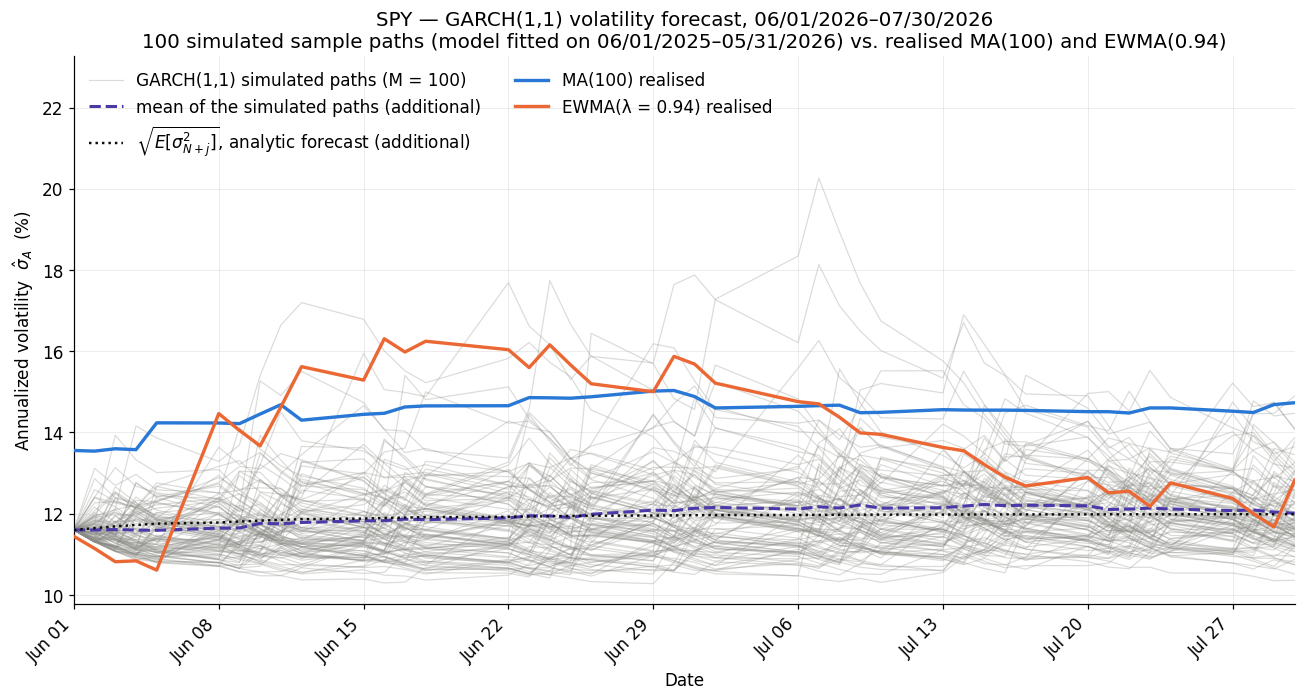

In [14]:
ma_fc   = ma_vol_ann.reindex(fc_dates)
ewma_fc = ewma_vol_ann.reindex(fc_dates)
assert ma_fc.notna().all() and ewma_fc.notna().all(), "MA/EWMA missing on some forecast dates."

fig, ax = plt.subplots(figsize=(12, 6.5))

for p in range(M_PATHS):
    ax.plot(fc_dates, 100 * sim_vol_ann[p], color=C_PATHS, lw=0.8, alpha=0.30,
            zorder=1, label=f"GARCH(1,1) simulated paths (M = {M_PATHS})" if p == 0 else None)

ax.plot(fc_dates, 100 * sim_vol_ann.mean(axis=0), color=C_MEAN, lw=2.0, ls="--", zorder=3,
        label="mean of the simulated paths (additional)")
ax.plot(fc_dates, 100 * analytic_vol_ann, color=C_INK, lw=1.6, ls=":", zorder=3,
        label=r"$\sqrt{E[\sigma^2_{N+j}]}$, analytic forecast (additional)")
ax.plot(fc_dates, 100 * ma_fc.to_numpy(),   color=C_MA,   lw=2.2, zorder=4,
        label=f"MA({N_MA}) realised")
ax.plot(fc_dates, 100 * ewma_fc.to_numpy(), color=C_EWMA, lw=2.2, zorder=4,
        label=f"EWMA(λ = {LAM}) realised")

ax.set_title(f"SPY — GARCH(1,1) volatility forecast, "
             f"{pd.Timestamp(FC_START):%m/%d/%Y}–{pd.Timestamp(FC_END):%m/%d/%Y}\n"
             f"{M_PATHS} simulated sample paths (model fitted on "
             f"{pd.Timestamp(FIT_START):%m/%d/%Y}–{pd.Timestamp(FIT_END):%m/%d/%Y}) "
             f"vs. realised MA({N_MA}) and EWMA({LAM})")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility  $\\hat{\\sigma}_{A}$  (%)")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_xlim(fc_dates[0], fc_dates[-1])

# y-range driven by the data, with head-room so the legend never sits on a path
_lo = 100 * min(sim_vol_ann.min(), ma_fc.min(), ewma_fc.min())
_hi = 100 * max(sim_vol_ann.max(), ma_fc.max(), ewma_fc.max())
ax.set_ylim(max(0.0, _lo - 0.05 * (_hi - _lo)), _hi + 0.30 * (_hi - _lo))
ax.legend(loc="upper left", ncol=2)
fig.autofmt_xdate(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG2_PATH, dpi=FIG_DPI, bbox_inches="tight")
print(f"saved {FIG2_PATH.resolve()}")
plt.show()

---
## 13. Final numerical outputs

Everything that has to be copied into the written PDF, in one place.

In [15]:
line = "=" * 78
print(line); print("SUMMARY OF RESULTS  —  copy these into the written PDF"); print(line)

print("\n[DATA]")
print(f"  source                : Yahoo Finance via yfinance, ticker {TICKER}, "
      f"raw Close (auto_adjust=False)")
print(f"  price observations    : {len(close)}   "
      f"{close.index[0].date()} -> {close.index[-1].date()}")
print(f"  log returns           : {len(x)}   {x.index[0].date()} -> {x.index[-1].date()}")

print("\n[Q1] ANNUALISED VOLATILITY, "
      f"{pd.Timestamp(PLOT_START):%m/%d/%Y} - {pd.Timestamp(PLOT_END):%m/%d/%Y}"
      f"   ({len(ma_plot)} trading days)")
tbl = pd.DataFrame({
    f"MA({N_MA}) %":    100 * ma_plot,
    f"EWMA({LAM}) %":   100 * ewma_plot,
})
print(f"  mean    : MA {tbl.iloc[:,0].mean():6.2f}%   EWMA {tbl.iloc[:,1].mean():6.2f}%")
print(f"  median  : MA {tbl.iloc[:,0].median():6.2f}%   EWMA {tbl.iloc[:,1].median():6.2f}%")
print(f"  minimum : MA {tbl.iloc[:,0].min():6.2f}% on {tbl.iloc[:,0].idxmin().date()}"
      f"   EWMA {tbl.iloc[:,1].min():6.2f}% on {tbl.iloc[:,1].idxmin().date()}")
print(f"  maximum : MA {tbl.iloc[:,0].max():6.2f}% on {tbl.iloc[:,0].idxmax().date()}"
      f"   EWMA {tbl.iloc[:,1].max():6.2f}% on {tbl.iloc[:,1].idxmax().date()}")
print(f"  final   : {tbl.index[-1].date()}  MA {tbl.iloc[-1,0]:6.2f}%   EWMA {tbl.iloc[-1,1]:6.2f}%")
print(f"  correlation of the two series : {tbl.iloc[:,0].corr(tbl.iloc[:,1]):.4f}")
print(f"  EWMA is more variable: sd(MA) = {tbl.iloc[:,0].std():.2f} pp, "
      f"sd(EWMA) = {tbl.iloc[:,1].std():.2f} pp")

print("\n[Q2] GARCH(1,1) FITTED BY MLE ON "
      f"{pd.Timestamp(FIT_START):%m/%d/%Y} - {pd.Timestamp(FIT_END):%m/%d/%Y}")
print(f"  trading observations used : {len(fit_prices)} closing prices -> {len(x_fit)} log returns")
print(f"  first / last return date  : {x_fit.index[0].date()} / {x_fit.index[-1].date()}")
print(f"  alpha_0 = {alpha0:.6e}")
print(f"  alpha_1 = {alpha1:.6f}")
print(f"  beta_1  = {beta1:.6f}")
print(f"  alpha_1 + beta_1 = {alpha1 + beta1:.6f}  (< 1, stationary)")
print(f"  V_L = alpha_0/(1 - alpha_1 - beta_1) = {V_L:.6e}")
print(f"  long-run volatility = {np.sqrt(V_L)*100:.4f}% per day = "
      f"{np.sqrt(V_L/DELTA)*100:.2f}% annualised")
print(f"  minimised -l(theta) = {nll_raw:.6f}     "
      f"ln L = {-0.5*(n_fit*np.log(2*np.pi) + nll_raw):.4f}")

print("\n[Q3] FORECAST "
      f"{pd.Timestamp(FC_START):%m/%d/%Y} - {pd.Timestamp(FC_END):%m/%d/%Y}"
      f"   ({m_days} trading days, M = {M_PATHS} paths, seed = {SEED})")
q = np.percentile(sim_vol_ann, [5, 50, 95], axis=0) * 100
rows = [(0, "first day"), (m_days // 2, "mid-horizon"), (m_days - 1, "last day")]
print(f"  {'day':<12}{'date':<12}{'p5':>8}{'median':>9}{'p95':>8}{'mean':>8}"
      f"{'MA':>8}{'EWMA':>8}")
for j, lbl in rows:
    print(f"  {lbl:<12}{fc_dates[j].date()!s:<12}{q[0,j]:>8.2f}{q[1,j]:>9.2f}{q[2,j]:>8.2f}"
          f"{sim_vol_ann[:,j].mean()*100:>8.2f}{ma_fc.iloc[j]*100:>8.2f}{ewma_fc.iloc[j]*100:>8.2f}")
print(f"  mean over the whole horizon : simulated {sim_vol_ann.mean()*100:.2f}%   "
      f"MA {ma_fc.mean()*100:.2f}%   EWMA {ewma_fc.mean()*100:.2f}%")
print(f"  analytic sqrt(E[sigma^2]) on the last day = {analytic_vol_ann[-1]*100:.2f}%   "
      f"long-run level = {np.sqrt(V_L/DELTA)*100:.2f}%")
frac = float(np.mean((sim_vol_ann[:, -1] >= ma_fc.iloc[-1]).astype(float)))
print(f"  share of paths above the realised MA on the last day : {frac*100:.0f}%")

print("\n[FILES]")
for f in (CSV_PATH, FIG1_PATH, FIG2_PATH):
    print(f"  {f.resolve()}  ({'exists' if f.exists() else 'MISSING'})")
print(line)

SUMMARY OF RESULTS  —  copy these into the written PDF

[DATA]
  source                : Yahoo Finance via yfinance, ticker SPY, raw Close (auto_adjust=False)
  price observations    : 1399   2021-01-04 -> 2026-07-30
  log returns           : 1398   2021-01-05 -> 2026-07-30

[Q1] ANNUALISED VOLATILITY, 08/01/2021 - 07/30/2026   (1254 trading days)
  mean    : MA  16.14%   EWMA  15.83%
  median  : MA  13.57%   EWMA  13.56%
  minimum : MA   9.58% on 2025-10-06   EWMA   7.30% on 2025-10-08
  maximum : MA  27.94% on 2025-05-13   EWMA  51.77% on 2025-04-11
  final   : 2026-07-30  MA  14.73%   EWMA  12.82%
  correlation of the two series : 0.7468
  EWMA is more variable: sd(MA) = 5.76 pp, sd(EWMA) = 6.64 pp

[Q2] GARCH(1,1) FITTED BY MLE ON 06/01/2025 - 05/31/2026
  trading observations used : 250 closing prices -> 249 log returns
  first / last return date  : 2025-06-03 / 2026-05-29
  alpha_0 = 6.753055e-06
  alpha_1 = 0.057997
  beta_1  = 0.823639
  alpha_1 + beta_1 = 0.881637  (< 1, stati

---
## 14. Self-checks

Assertions covering the points that are easy to get wrong: annualization,
variance-versus-volatility, window lengths, indexing, absence of look-ahead bias,
the number of simulated paths, and reproducibility of the seed. The cell prints
`ALL CHECKS PASSED` if the notebook is internally consistent.

In [16]:
checks = []


def check(name, ok):
    checks.append((name, bool(ok)))


def same(a, b, rtol=1e-12):
    """Equal to within floating-point round-off.

    Two mathematically identical quantities computed by different code paths
    (our explicit loop vs. pandas/numpy reductions) can differ by an ulp or two,
    and an ulp at a daily variance of 1e-4 is about 5e-20. A relative test is the
    only version-independent way to compare them.
    """
    a, b = float(a), float(b)
    return abs(a - b) <= rtol * max(abs(a), abs(b), 1e-300)


# --- returns -----------------------------------------------------------------
check("log returns, not simple returns",
      same(x.iloc[5], np.log(close.iloc[6] / close.iloc[5])))
check("one fewer return than prices", len(x) == len(close) - 1)
check("return dated on the later day", x.index[0] == close.index[1])

# --- MA ----------------------------------------------------------------------
_i = 400
_w = x.iloc[_i - N_MA + 1: _i + 1]
check("MA window length is exactly n = 100", len(_w) == N_MA)
check("MA uses mean-removed, n-1 denominator",
      same(ma_var.iloc[_i], ((_w - _w.mean()) ** 2).sum() / (N_MA - 1)))
check("MA includes today's return",
      same(ma_var.iloc[_i], x.iloc[_i - N_MA + 1: _i + 1].var(ddof=1)))
check("MA undefined before the 100th return", bool(np.isnan(ma_var.iloc[N_MA - 2])))
check("MA defined from the 100th return", bool(np.isfinite(ma_var.iloc[N_MA - 1])))

# --- EWMA --------------------------------------------------------------------
check("EWMA initialised with the MA(100) sample variance",
      same(ewma_var.iloc[N_MA - 1], ma_var.iloc[N_MA - 1]))
check("EWMA recursion uses x_{i-1}, not x_i",
      same(ewma_var.iloc[_i], LAM * ewma_var.iloc[_i - 1] + (1 - LAM) * x.iloc[_i - 1] ** 2))
check("EWMA weights sum to one", abs(LAM + (1 - LAM) - 1.0) < 1e-15)

# --- no look-ahead -----------------------------------------------------------
_cut = 600
_x_trunc = x.iloc[: _cut + 1]
check("MA at day i unchanged when the future is deleted",
      same(ma_variance(_x_trunc, N_MA).iloc[_cut], ma_var.iloc[_cut]))
check("EWMA at day i unchanged when the future is deleted",
      same(ewma_variance(_x_trunc, LAM, N_MA - 1, ewma_var0).iloc[_cut], ewma_var.iloc[_cut]))

# --- annualisation -----------------------------------------------------------
check("Delta = 1/252", abs(DELTA - 1 / 252) < 1e-15)
check("annualised vol = daily vol x sqrt(252), not x 252",
      same(ma_vol_ann.iloc[_i], np.sqrt(ma_var.iloc[_i]) * np.sqrt(252)))
check("annualised variance = daily variance / Delta",
      same(ma_vol_ann.iloc[_i] ** 2, ma_var.iloc[_i] / DELTA))

# --- plot windows ------------------------------------------------------------
check("Q1 window starts on/after 08/01/2021", ma_plot.index[0] >= pd.Timestamp(PLOT_START))
check("Q1 window ends on/before 07/30/2026", ma_plot.index[-1] <= pd.Timestamp(PLOT_END))
check("Q1 window has no gaps", ma_plot.notna().all() and ewma_plot.notna().all())

# --- GARCH -------------------------------------------------------------------
check("fit window inside 06/01/2025-05/31/2026",
      (fit_prices.index[0] >= pd.Timestamp(FIT_START)) and
      (fit_prices.index[-1] <= pd.Timestamp(FIT_END)))
check("alpha_0 > 0", alpha0 > 0)
check("alpha_1, beta_1 >= 0", (alpha1 >= 0) and (beta1 >= 0))
check("alpha_1 + beta_1 < 1", (alpha1 + beta1) < 1)
check("V_L consistent with the parameters",
      same(V_L, alpha0 / (1 - alpha1 - beta1)))
check("filtered variance obeys the recursion",
      same(sigma2_filtered.iloc[10],
           alpha0 + alpha1 * r_raw[9] ** 2 + beta1 * sigma2_filtered.iloc[9]))

# --- simulation --------------------------------------------------------------
check(f"exactly M = {M_PATHS} paths", sim_var.shape[0] == M_PATHS)
check("one forecast value per forecast trading day", sim_var.shape[1] == len(fc_dates))
check("forecast dates inside 06/01/2026-07/30/2026",
      (fc_dates[0] >= pd.Timestamp(FC_START)) and (fc_dates[-1] <= pd.Timestamp(FC_END)))
check("all simulated variances strictly positive", bool(np.all(sim_var > 0)))
check("day 1 identical on every path (F_N-measurable)",
      float(np.ptp(sim_var[:, 0])) <= 1e-12 * float(sim_var[:, 0].mean()))
check("simulation reproducible from the seed",
      np.allclose(np.random.default_rng(SEED).standard_normal((M_PATHS, m_days)), Z))
check("Monte-Carlo mean variance close to the analytic forecast",
      abs(sim_var[:, -1].mean() / analytic_var[-1] - 1.0) < 0.35)

# --- files -------------------------------------------------------------------
check("SPY_data.csv written", CSV_PATH.exists())
check("ma_ewma_volatility.png written", FIG1_PATH.exists())
check("garch_forecast_comparison.png written", FIG2_PATH.exists())

width = max(len(n) for n, _ in checks) + 2
for name, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {name:<{width}}")
failed = [n for n, ok in checks if not ok]
print("\n" + ("ALL CHECKS PASSED" if not failed else f"{len(failed)} CHECK(S) FAILED: {failed}"))
assert not failed

  PASS  log returns, not simple returns                           
  PASS  one fewer return than prices                              
  PASS  return dated on the later day                             
  PASS  MA window length is exactly n = 100                       
  PASS  MA uses mean-removed, n-1 denominator                     
  PASS  MA includes today's return                                
  PASS  MA undefined before the 100th return                      
  PASS  MA defined from the 100th return                          
  PASS  EWMA initialised with the MA(100) sample variance         
  PASS  EWMA recursion uses x_{i-1}, not x_i                      
  PASS  EWMA weights sum to one                                   
  PASS  MA at day i unchanged when the future is deleted          
  PASS  EWMA at day i unchanged when the future is deleted        
  PASS  Delta = 1/252                                             
  PASS  annualised vol = daily vol x sqrt(252), not x 252     